In [13]:
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message="Detected IPython.*")

import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import networkx as nx

import plotly.express as px
from pathlib import Path
import sklearn
import numpy as np


from pygam import LinearGAM, s
from sklearn.linear_model import LinearRegression
from pysr import PySRRegressor
from sklearn.metrics import r2_score
import re

import pyarrow.parquet as pq

current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
import math

def plot_causal_graph(G, title="Causal Graph", figsize=(15, 10)):
    """
    Plot a directed causal graph with extra‑separated variables
    and very small arrowheads and light connecting lines.
    """
    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.axis("off")

    # Layout: increase k for stronger repulsion between nodes
    # 3–5 for moderate graphs, up to 7–10 for dense/large graphs
    pos = nx.spring_layout(G, k=6.0, iterations=400, seed=42)

    node_radius = 0.05  # approximate visual node radius

    # --- Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos,
        node_color="#c6dcef",
        node_size=2200,
        edgecolors="black",
        linewidths=0.8,
        ax=ax,
    )

    # --- Draw labels ---
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)

    # --- Draw fine arrows ---
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        dx, dy = x1 - x0, y1 - y0
        dist = math.hypot(dx, dy)
        shrink = node_radius / dist
        x0s = x0 + dx * shrink
        y0s = y0 + dy * shrink
        x1s = x1 - dx * shrink
        y1s = y1 - dy * shrink

        ax.annotate(
            "",
            xy=(x1s, y1s),
            xytext=(x0s, y0s),
            arrowprops=dict(
                arrowstyle="simple,head_length=1.5,head_width=1.0,tail_width=0.2",
                color="#023047",
                lw=0.6,
            ),
        )

    plt.tight_layout()
    plt.show()

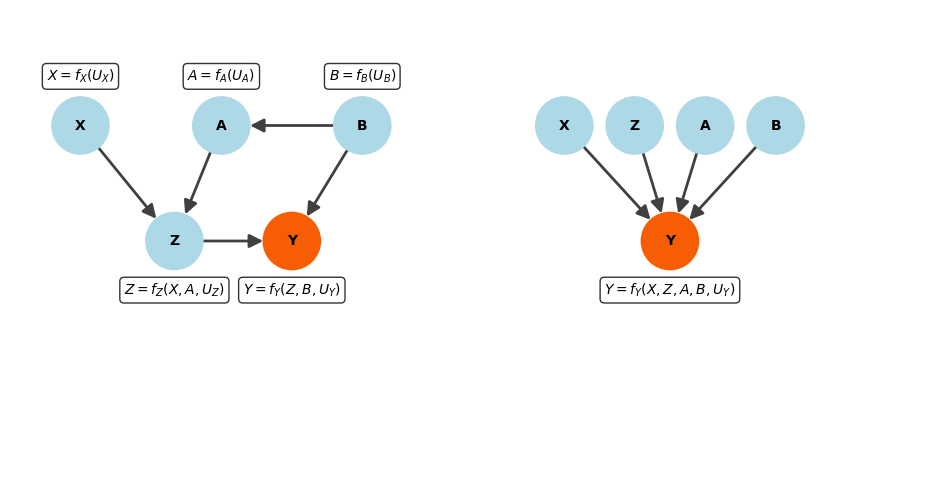

In [15]:
# Create graph for example of SCM  for static causal graph

def draw_custom_graph(ax, edges, positions, labels=None, y_threshold=0.7):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Node colors: orange for Y, light blue otherwise
    node_colors = ["#F75D03" if node == 'Y' else 'lightblue' for node in G.nodes()]

    # Use provided labels if given, else defaults
    if labels is None:
        labels = {node: node for node in G.nodes()}

    # Draw the graph (nodes and edges, but no labels yet)
    nx.draw(
        G, pos=positions, ax=ax,
        with_labels=False,
        node_size=1700,
        node_color=node_colors,
        edge_color='#404040',
        arrows=True,
        arrowsize=20,
        width=2
    )

    # --- Draw the node names inside the nodes ---
    for node in G.nodes():
        x, y = positions[node]
        ax.text(
            x, y, node,
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='black'
        )

    # --- Draw the external formula labels above or below nodes ---
    for node, label in labels.items():
        x, y = positions[node]
        # Determine vertical offset and alignment based on position
        if y > y_threshold:
            va = 'bottom'; dy = 0.07  # label above node
        else:
            va = 'top'; dy = -0.07   # label below node
        ax.text(
            x, y + dy, label,
            ha='center', va=va,
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

    ax.set_xlim(0, 1.8)
    ax.set_ylim(0.3, 1.1)
    ax.axis('off')


# ==========================================================
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=False)
plt.subplots_adjust(wspace=0.2)

# ---------- LEFT GRAPH ----------
edges_original = [
    ('X', 'Z'),   # X → Z
    ('Z', 'Y'),   # Z → Y
    ('A', 'Z'),   # A → Z
    ('B', 'Y'),   # B → Y
    ('B', 'A')    # B → A
]
positions_left = {
    'X': (0.3, 0.9),
    'Z': (0.7, 0.7),
    'Y': (1.2, 0.7),
    'A': (0.9, 0.9),
    'B': (1.5, 0.9),
}
labels_left = {
    'X': r'$X = f_X(U_X)$',
    'Z': r'$Z = f_Z(X, A, U_Z)$',
    'Y': r'$Y = f_Y(Z, B, U_Y)$',
    'A': r'$A = f_A(U_A)$',
    'B': r'$B = f_B(U_B)$'
}
draw_custom_graph(axes[0], edges_original, positions_left, labels=labels_left)

# ---------- RIGHT GRAPH ----------
edges_all_to_Y = [
    ('X', 'Y'),
    ('Z', 'Y'),
    ('A', 'Y'),
    ('B', 'Y')
]
positions_right = {
    'X': (0.2, 0.9),
    'Z': (0.5, 0.9),
    'A': (0.8, 0.9),
    'B': (1.1, 0.9),
    'Y': (0.65, 0.7),
}
labels_right = {
    'Y': r'$Y = f_Y(X, Z, A, B, U_Y)$'
}
draw_custom_graph(axes[1], edges_all_to_Y, positions_right, labels=labels_right)

# Save or display
plt.savefig('visuals/static_SCM.pdf', bbox_inches='tight', pad_inches=0.02, dpi=400, format='pdf')
plt.show()

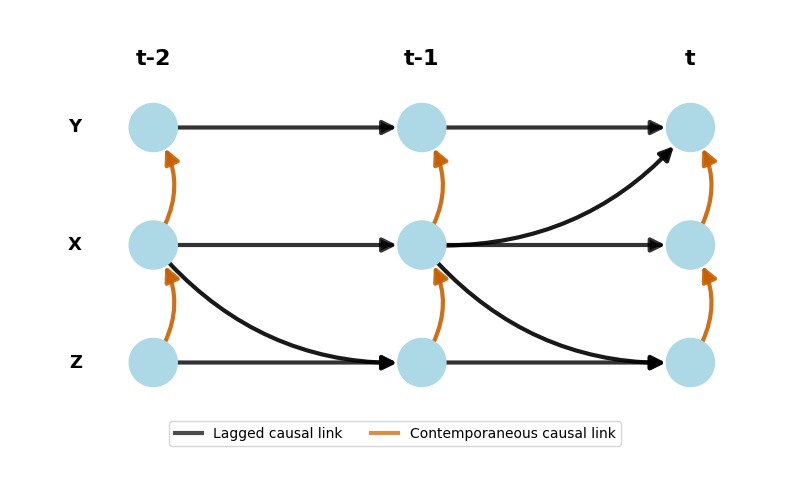

In [16]:
# Create graph for example of dynamic causal graph

# Define variable names
var_names = ['Y', 'X', 'Z']

# Define causal relationships for causal graph
causal_links_causal = {
    'X_t_2': ['Z_t_2'],
    'Y_t_2': ['X_t_2'],
    'X_t_1': ['Y_t_2'],
    'Z_t_1': ['X_t_2'],
    'X_t_1': ['Z_t_1'],
    'Y_t_1': ['X_t_1'],
    'X_t': ['Z_t'],
    'Y_t': ['X_t_1', 'X_t'],
    'Z_t': ['X_t_1'],
}

# Define structural equations for each node (not used in this version)
structural_equations_causal = {
    'Y_t_2': r'$Y_{t-2} = f_Y(X_{t-2}, U^Y_{t-2})$',
    'X_t_2': r'$X_{t-2} = f_X(Z_{t-2}, U^X_{t-2})$',
    'Z_t_2': r'$Z_{t-2} = f_Z(U^Z_{t-2})$',
    'Y_t_1': r'$Y_{t-1} = f_Y(Y_{t-2}, X_{t-1}, U^Y_{t-1})$',
    'X_t_1': r'$X_{t-1} = f_X(X_{t-2}, Y_{t-2}, Z_{t-1}, U^X_{t-1})$',
    'Z_t_1': r'$Z_{t-1} = f_Z(Z_{t-2}, X_{t-2}, U^Z_{t-1})$',
    'Y_t':  r'$Y_t = f_Y(Y_{t-1}, X_{t-1}, X_t, U^Y_t)$',
    'X_t':  r'$X_t = f_X(X_{t-1}, Z_t, U^X_t)$',
    'Z_t':  r'$Z_t = f_Z(Z_{t-1}, X_{t-1}, U^Z_t)$',
}


# Function to create and visualize causal graph
def create_and_visualize_causal_graph(ax, var_names, causal_links, include_auto=True):
    G = nx.DiGraph()

    nodes_t_2 = [f"{var}_t_2" for var in var_names]
    nodes_t_1 = [f"{var}_t_1" for var in var_names]
    nodes_t  = [f"{var}_t"  for var in var_names]
    G.add_nodes_from(nodes_t_2 + nodes_t_1 + nodes_t)

    if include_auto:
        for var in var_names:
            G.add_edge(f"{var}_t_2", f"{var}_t_1")
            G.add_edge(f"{var}_t_1", f"{var}_t")

    for target, predictors in causal_links.items():
        for pred in predictors:
            G.add_edge(pred, target)

    spacing_y = 0.8  
    spacing_x = 1.5  
    pos = {}
    for i, var in enumerate(var_names):
        pos[f"{var}_t_2"] = (0, -i * spacing_y)
        pos[f"{var}_t_1"] = (spacing_x, -i * spacing_y)
        pos[f"{var}_t"]  = (2 * spacing_x, -i * spacing_y)

    if include_auto:
        auto_edges = [(f"{var}_t_2", f"{var}_t_1") for var in var_names] + \
                     [(f"{var}_t_1", f"{var}_t") for var in var_names]
    lagged_edges = []
    lateral_t_2, lateral_t_1, lateral_t = [], [], []
    for e in G.edges():
        if include_auto and e in auto_edges:
            continue
        elif e[0].endswith('_t_2') and e[1].endswith('_t_2'):
            lateral_t_2.append(e)
        elif e[0].endswith('_t_1') and e[1].endswith('_t_1'):
            lateral_t_1.append(e)
        elif e[0].endswith('_t') and e[1].endswith('_t'):
            lateral_t.append(e)
        else:
            lagged_edges.append(e)

    node_size = 1200  # Reduced node size to fit closer spacing

    if include_auto:
        nx.draw_networkx_edges(G, pos, edgelist=auto_edges, arrows=True,
                               width=3, arrowsize=20, edge_color='black',
                               connectionstyle='arc3,rad=0', ax=ax, alpha=0.8,
                               node_size=node_size, min_target_margin=18)

    nx.draw_networkx_edges(G, pos, edgelist=lagged_edges, arrows=True,
                           width=3, arrowsize=20, edge_color='black',
                           connectionstyle='arc3,rad=0.25', ax=ax, alpha=0.9,
                           node_size=node_size, min_target_margin=18)

    def draw_contemp(edges):
        for edge in edges:
            src_idx = var_names.index(edge[0].split('_')[0])
            tgt_idx = var_names.index(edge[1].split('_')[0])
            rad = -0.35 if src_idx < tgt_idx else 0.35
            nx.draw_networkx_edges(G, pos, edgelist=[edge], arrows=True,
                                   width=3, arrowsize=22, edge_color='#C76000',
                                   connectionstyle=f'arc3,rad={rad}', ax=ax, alpha=0.9,
                                   node_size=node_size, min_target_margin=16)
    draw_contemp(lateral_t_2)
    draw_contemp(lateral_t_1)
    draw_contemp(lateral_t)

    # Define node colors: orange for Y_t, lightblue for others
    node_colors = ['lightblue' if node == 'Y_t' else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)

    for i, var in enumerate(var_names):
        ax.text(-0.4, -i * spacing_y, var, ha='right', va='center',  # Adjusted left text position
                fontsize=13, fontweight='bold')

    header_offset = 0.4  # Reduced header offset
    ax.text(0, header_offset, 't-2', ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(spacing_x, header_offset, 't-1', ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(2 * spacing_x, header_offset, 't', ha='center', va='bottom', fontsize=16, fontweight='bold')

    if include_auto:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='black', lw=3, alpha=0.7, label='Lagged causal link'),
            Line2D([0], [0], color='#C76000', lw=3, alpha=0.7, label='Contemporaneous causal link')
        ]
        ax.legend(handles=legend_elements, loc='upper center', fontsize=10,
                  ncol=3, bbox_to_anchor=(0.5, 0.14))

    ax.set_xlim(-0.8, 2 * spacing_x + 0.5)  # Adjusted xlim
    ax.set_ylim(-(len(var_names) - 1) * spacing_y - 0.8, 0.8)  # Adjusted ylim
    ax.axis('off')

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))  

# Causal graph
create_and_visualize_causal_graph(ax, var_names, causal_links_causal, include_auto=True)

plt.tight_layout()
plt.savefig('visuals/dynamic_CG.pdf', bbox_inches='tight', pad_inches=0.02, dpi=400, format='pdf')
plt.show()

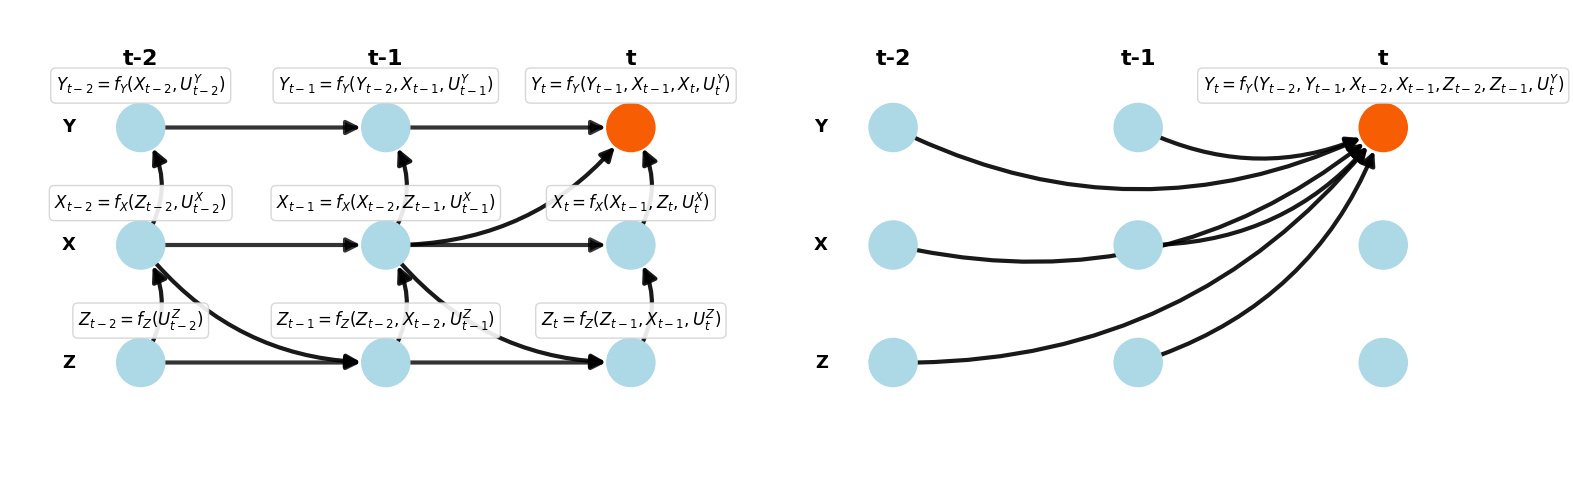

In [17]:
# Create graph for example of SCM  for dynamic causal graph

# Define variable names
var_names = ['Y', 'X', 'Z']

# Define causal relationships for causal graph
causal_links_causal = {
    'X_t_2': ['Z_t_2'],
    'Y_t_2': ['X_t_2'],
    'X_t_1': ['Y_t_2'],
    'Z_t_1': ['X_t_2'],
    'X_t_1': ['Z_t_1'],
    'Y_t_1': ['X_t_1'],
    'X_t0': ['Z_t0'],
    'Y_t0': ['X_t_1', 'X_t0'],
    'Z_t0': ['X_t_1'],
}

# Define causal relationships for non-causal graph
causal_links_noncausal = {
    'Y_t0': ['X_t_1', 'X_t_2', 'Y_t_1', 'Y_t_2', 'Z_t_1', 'Z_t_2'],
}

# Define structural equations for each node
structural_equations_causal = {
    'Y_t_2': r'$Y_{t-2} = f_Y(X_{t-2}, U^Y_{t-2})$',
    'X_t_2': r'$X_{t-2} = f_X(Z_{t-2}, U^X_{t-2})$',
    'Z_t_2': r'$Z_{t-2} = f_Z(U^Z_{t-2})$',

    'Y_t_1': r'$Y_{t-1} = f_Y(Y_{t-2}, X_{t-1}, U^Y_{t-1})$',
    'X_t_1': r'$X_{t-1} = f_X(X_{t-2}, Z_{t-1}, U^X_{t-1})$',
    'Z_t_1': r'$Z_{t-1} = f_Z(Z_{t-2}, X_{t-2}, U^Z_{t-1})$',

    'Y_t0':  r'$Y_t = f_Y(Y_{t-1}, X_{t-1}, X_t, U^Y_t)$',
    'X_t0':  r'$X_t = f_X(X_{t-1}, Z_t, U^X_t)$',
    'Z_t0':  r'$Z_t = f_Z(Z_{t-1}, X_{t-1}, U^Z_t)$',
}

structural_equations_noncausal = {
    'Y_t0':  r'$Y_t = f_Y(Y_{t-2}, Y_{t-1}, X_{t-2},X_{t-1}, Z_{t-2}, Z_{t-1}, U^Y_t)$',
}

# Function to create and visualize causal graph
def create_and_visualize_causal_graph(ax, var_names, causal_links, structural_equations, include_auto=True):
    G = nx.DiGraph()

    nodes_t_2 = [f"{var}_t_2" for var in var_names]
    nodes_t_1 = [f"{var}_t_1" for var in var_names]
    nodes_t0  = [f"{var}_t0"  for var in var_names]
    G.add_nodes_from(nodes_t_2 + nodes_t_1 + nodes_t0)

    if include_auto:
        for var in var_names:
            G.add_edge(f"{var}_t_2", f"{var}_t_1")
            G.add_edge(f"{var}_t_1", f"{var}_t0")

    for target, predictors in causal_links.items():
        for pred in predictors:
            G.add_edge(pred, target)

    spacing_y = 0.8  
    spacing_x = 1.5 
    pos = {}
    for i, var in enumerate(var_names):
        pos[f"{var}_t_2"] = (0, -i * spacing_y)
        pos[f"{var}_t_1"] = (spacing_x, -i * spacing_y)
        pos[f"{var}_t0"]  = (2 * spacing_x, -i * spacing_y)

    if include_auto:
        auto_edges = [(f"{var}_t_2", f"{var}_t_1") for var in var_names] + \
                     [(f"{var}_t_1", f"{var}_t0") for var in var_names]
    lagged_edges = []
    lateral_t_2, lateral_t_1, lateral_t0 = [], [], []
    for e in G.edges():
        if include_auto and e in auto_edges:
            continue
        elif e[0].endswith('_t_2') and e[1].endswith('_t_2'):
            lateral_t_2.append(e)
        elif e[0].endswith('_t_1') and e[1].endswith('_t_1'):
            lateral_t_1.append(e)
        elif e[0].endswith('_t0') and e[1].endswith('_t0'):
            lateral_t0.append(e)
        else:
            lagged_edges.append(e)

    node_size = 1200  # Reduced node size to fit closer spacing

    if include_auto:
        nx.draw_networkx_edges(G, pos, edgelist=auto_edges, arrows=True,
                               width=3, arrowsize=20, edge_color='black',
                               connectionstyle='arc3,rad=0', ax=ax, alpha=0.8,
                               node_size=node_size, min_target_margin=18)

    nx.draw_networkx_edges(G, pos, edgelist=lagged_edges, arrows=True,
                           width=3, arrowsize=20, edge_color='black',
                           connectionstyle='arc3,rad=0.25', ax=ax, alpha=0.9,
                           node_size=node_size, min_target_margin=18)

    def draw_contemp(edges):
        for edge in edges:
            src_idx = var_names.index(edge[0].split('_')[0])
            tgt_idx = var_names.index(edge[1].split('_')[0])
            rad = -0.35 if src_idx < tgt_idx else 0.35
            nx.draw_networkx_edges(G, pos, edgelist=[edge], arrows=True,
                                   width=3, arrowsize=22, edge_color='black',
                                   connectionstyle=f'arc3,rad={rad}', ax=ax, alpha=0.9,
                                   node_size=node_size, min_target_margin=16)
    draw_contemp(lateral_t_2)
    draw_contemp(lateral_t_1)
    draw_contemp(lateral_t0)

    # Define node colors: orange for Y_t0, lightblue for others
    node_colors = ["#F75D03" if node == 'Y_t0' else 'lightblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)

    for i, var in enumerate(var_names):
        ax.text(-0.4, -i * spacing_y, var, ha='right', va='center',  # Adjusted left text position
                fontsize=13, fontweight='bold')

    header_offset = 0.4  # Reduced header offset
    ax.text(0, header_offset, 't-2', ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(spacing_x, header_offset, 't-1', ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(2 * spacing_x, header_offset, 't', ha='center', va='bottom', fontsize=16, fontweight='bold')

    equation_offset = 0.2  # Reduced equation offset
    for node in G.nodes():
        if node in structural_equations:
            x, y = pos[node]
            ax.text(
                x, y + equation_offset,
                structural_equations[node],
                ha='center', va='bottom',
                fontsize=12,  
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.9, edgecolor='lightgray')
            )

    ax.set_xlim(-0.8, 2 * spacing_x + 0.5)
    ax.set_ylim(-(len(var_names) - 1) * spacing_y - 0.8, 0.8)  
    ax.axis('off')

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 

# Left subplot: Causal graph
create_and_visualize_causal_graph(axes[0], var_names, causal_links_causal, structural_equations_causal, include_auto=True)

# Right subplot: Non-causal graph
create_and_visualize_causal_graph(axes[1], var_names, causal_links_noncausal, structural_equations_noncausal, include_auto=False)

plt.tight_layout()

plt.savefig('visuals/dynamic_SCM_combined.pdf', bbox_inches='tight', pad_inches=0.02, dpi=500, format='pdf')
plt.show()

R^2 (Linear Regression): 0.4797
R^2 (GAM): 0.9985
R^2 (Symbolic Regression): 0.9986
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     21.3198
Link Function:                     IdentityLink Log Likelihood:                                -15171.9584
Number of Samples:                          400 AIC:                                            30388.5564
                                                AICc:                                             30391.32
                                                GCV:                                                0.0126
                                                Scale:                                              0.0114
                                                Pseudo R-Squ

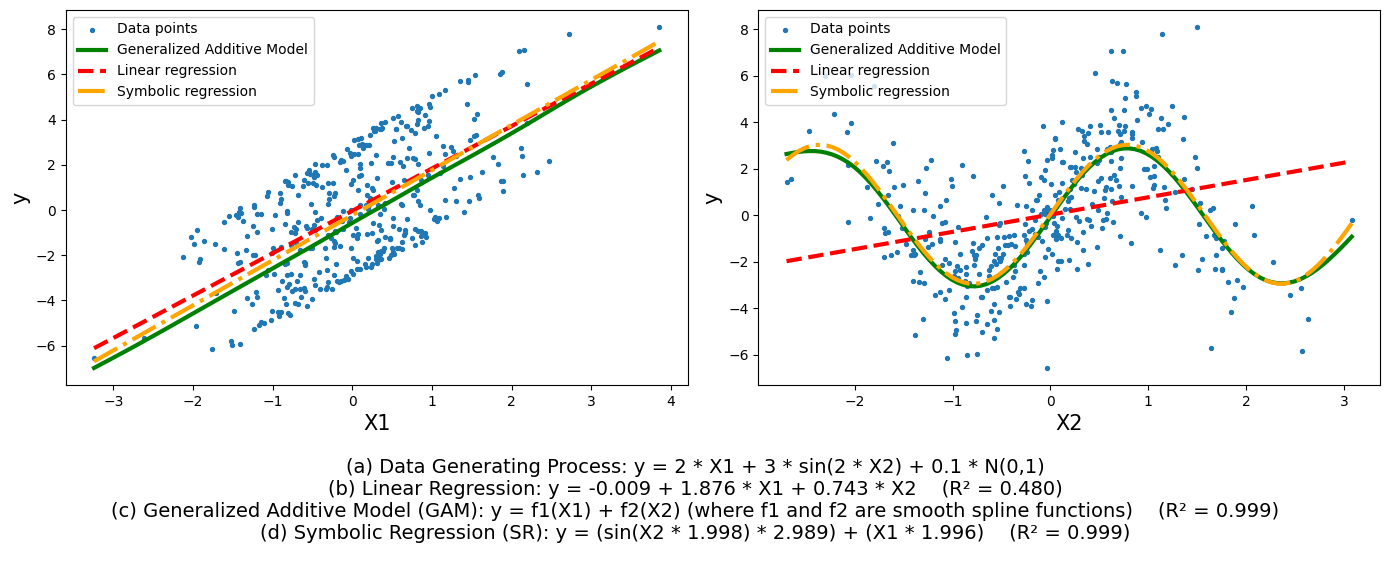

In [21]:
# Create example for GAM and SR

# Simple example sythetic data
np.random.seed(42)
n = 400
X1 = np.random.randn(n)
X2 = np.random.randn(n)
y = 2 * X1 + 3 * np.sin(2*X2) + 0.1 * np.random.randn(n) 

df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

# Define and fit GAM with smooth terms
gam = LinearGAM(s(0) + s(1))
gam.fit(df[['X1', 'X2']], df['y'])

# Fit linear regression
lr = LinearRegression()
lr.fit(df[['X1', 'X2']], df['y'])

# Fit symbolic regression
sr = PySRRegressor(
    maxsize=20,
    niterations=200,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["sin"],
    elementwise_loss="loss(prediction, target) = (prediction - target)^2",
    random_state=42,
    verbosity=0,
    progress=False,
)
sr.fit(df[['X1', 'X2']], df['y'])

# Get best equation and round numeric literals to 3 decimals
try:
    best_eq_raw = sr.get_best()['equation']
except Exception:
    best_eq_raw = "No equation available"

def _round_numbers_in_string(s, ndigits=3):
    import re
    def _repl(m):
        token = m.group(0)
        # only round if token has a decimal point or exponent; leave integers unchanged
        if '.' in token or 'e' in token.lower():
            try:
                v = float(token)
                return f"{v:.{ndigits}f}"
            except Exception:
                return token
        return token
    # match integers, floats, and scientific notation
    return re.sub(r'-?\d+\.?\d*(?:[eE][+-]?\d+)?', _repl, s)

best_eq = _round_numbers_in_string(best_eq_raw, ndigits=3)

# Predictions for plotting partial dependence
predictions = gam.predict(df[['X1', 'X2']])

# Compute R^2 for each model on the full dataset
X = df[['X1', 'X2']]
y_true = df['y'].values

gam_pred_full = gam.predict(X)
lr_pred_full = lr.predict(X)
sr_pred_full = sr.predict(X)

r2_gam = r2_score(y_true, gam_pred_full)
r2_lr = r2_score(y_true, lr_pred_full)
r2_sr = r2_score(y_true, sr_pred_full)

print(f"R^2 (Linear Regression): {r2_lr:.4f}")
print(f"R^2 (GAM): {r2_gam:.4f}")
print(f"R^2 (Symbolic Regression): {r2_sr:.4f}")

# Summary
print(gam.summary())

# Print the GAM function (fitted model details)
print("\nGAM fitted function:")
print(gam)

# Create subplots for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Partial dependence plot for first term (X1)
XX1 = gam.generate_X_grid(term=0)
pdep1 = gam.partial_dependence(term=0, X=XX1)

# Linear regression partial for X1 (hold X2 at mean)
X1_grid = np.linspace(df['X1'].min(), df['X1'].max(), 100)
X2_mean = df['X2'].mean()
lr_pred1 = lr.predict(np.column_stack([X1_grid, np.full_like(X1_grid, X2_mean)]))

# Symbolic regression partial for X1 (hold X2 at mean)
sr_pred1 = sr.predict(np.column_stack([X1_grid, np.full_like(X1_grid, X2_mean)]))

axes[0].scatter(df['X1'], df['y'], s=8, label='Data points')
axes[0].plot(XX1[:, 0], pdep1, label='Generalized Additive Model', color='green', linewidth=3)
axes[0].plot(X1_grid, lr_pred1, label='Linear regression', color='red', linestyle='--', linewidth=3)
axes[0].plot(X1_grid, sr_pred1, label='Symbolic regression', color='orange', linestyle='-.', linewidth=3)
axes[0].set_xlabel('X1', fontsize=15)
axes[0].set_ylabel('y', fontsize=15)
axes[0].legend()
axes[0].grid(False)

# Partial dependence plot for second term (X2)
XX2 = gam.generate_X_grid(term=1)
pdep2 = gam.partial_dependence(term=1, X=XX2)

# Linear regression partial for X2 (hold X1 at mean)
X2_grid = np.linspace(df['X2'].min(), df['X2'].max(), 100)
X1_mean = df['X1'].mean()
lr_pred2 = lr.predict(np.column_stack([np.full_like(X2_grid, X1_mean), X2_grid]))

# Symbolic regression partial for X2 (hold X1 at mean)
sr_pred2 = sr.predict(np.column_stack([np.full_like(X2_grid, X1_mean), X2_grid]))

axes[1].scatter(df['X2'], df['y'], s=8, label='Data points')
axes[1].plot(XX2[:, 1], pdep2, label='Generalized Additive Model', color='green', linewidth=3)
axes[1].plot(X2_grid, lr_pred2, label='Linear regression', color='red', linestyle='--', linewidth=3)
axes[1].plot(X2_grid, sr_pred2, label='Symbolic regression', color='orange', linestyle='-.', linewidth=3)
axes[1].set_xlabel('X2', fontsize=15)
axes[1].set_ylabel('y', fontsize=15)
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()

# Adjust bottom to make more room for text
plt.subplots_adjust(bottom=0.35)

# Add equations below the visuals with R^2 values
equations = f"""
(a) Data Generating Process: y = 2 * X1 + 3 * sin(2 * X2) + 0.1 * N(0,1)
(b) Linear Regression: y = {lr.intercept_:.3f} + {lr.coef_[0]:.3f} * X1 + {lr.coef_[1]:.3f} * X2    (R² = {r2_lr:.3f})
(c) Generalized Additive Model (GAM): y = f1(X1) + f2(X2) (where f1 and f2 are smooth spline functions)    (R² = {r2_gam:.3f})
(d) Symbolic Regression (SR): y = {best_eq}    (R² = {r2_sr:.3f})
"""
fig.text(0.5, 0.05, equations, ha='center', va='bottom', fontsize=14, wrap=True)

plt.savefig('visuals' + '/gam_vs_linear.pdf', dpi=500, format='pdf', bbox_inches='tight')
plt.show()